use k=11, train on more data and test on lab data

In [3]:
import sys
sys.path.insert(0, r"C:\Users\20242732\Desktop\cbl\cbl_predictive_new\4cblw010\src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, cross_val_score
from cbl.utils import get_labels
from cbl.data.transforms import Interpolate



In [4]:
import pyarrow.parquet as pq

pf = pq.ParquetFile(r"C:\Users\20242732\Desktop\cbl\cbl_predictive_new\4cblw010\src\cbl\data\merged.parquet")

rare_chunks, common_chunks = [], []
CLASS_NAMES = ['carboxylic_acid', 'amino', 'sulfonic_acid', 'guanidino']

for batch in pf.iter_batches(batch_size=10_000, columns=['wavenumber', 'transmittance'] + CLASS_NAMES):
    chunk = batch.to_pandas()
    mask_rare = (chunk['sulfonic_acid'] == 1) | (chunk['guanidino'] == 1)
    rare_chunks.append(chunk[mask_rare])
    common_chunks.append(chunk[~mask_rare])

df_rare   = pd.concat(rare_chunks).reset_index(drop=True)
df_common = pd.concat(common_chunks).sample(n=10_000, random_state=42).reset_index(drop=True)
df_train  = pd.concat([df_rare, df_common]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Training subset size:", len(df_train))
for col in CLASS_NAMES:
    print(f"  {col}: {int(df_train[col].sum())}")

Training subset size: 13215
  carboxylic_acid: 4427
  amino: 7820
  sulfonic_acid: 77
  guanidino: 3145


In [7]:
transform = Interpolate((4000, 400), 1800)

spectra_list = []
for _, row in df_train.iterrows():
    wn = np.asarray(row['wavenumber'])
    tr = np.asarray(row['transmittance'])
    spectra_list.append(transform(wn, tr))

X_train = np.stack(spectra_list)
print(f"Train spectra shape: {X_train.shape}")
print(f"Train spectra range: [{X_train.min():.3f}, {X_train.max():.3f}]")

Train spectra shape: (13215, 1800)
Train spectra range: [0.000, 1.000]


In [6]:
ADULTERANT_SMILES = {
    'creatine': 'CN(CC(=O)O)C(=N)N',
    'taurine':  'NCCS(=O)(=O)O',
    'glycine':  'NCC(=O)O',
}

df_lab = pd.read_parquet(r'C:\Users\20242732\Desktop\cbl\cbl_predictive_new\4cblw010\src\cbl\data\lab_resampled.parquet')
df_lab['smiles'] = df_lab['adulterant'].map(ADULTERANT_SMILES)

# Drop pure base rows (no adulterant = no SMILES = no ground truth)
unmapped = df_lab['smiles'].isna().sum()
print(f"Dropping {unmapped} rows with no SMILES (pure base samples)")
df_lab = df_lab[df_lab['smiles'].notna()].copy()

# Apply functional group labels via get_labels
labels = df_lab['smiles'].apply(get_labels)
label_df = pd.DataFrame(labels.tolist(), index=df_lab.index)
df_lab = pd.concat([df_lab, label_df], axis=1)

# Apply same Interpolate transform as training data
lab_spectra = []
for _, row in df_lab.iterrows():
    wn = np.asarray(row['wavenumber'])
    tr = np.asarray(row['transmittance'])
    lab_spectra.append(transform(wn, tr))

X_lab_raw = np.stack(lab_spectra)
y_lab = df_lab[CLASS_NAMES].values

print(f"Lab samples: {X_lab_raw.shape[0]}")
print(f"Lab spectra range: [{X_lab_raw.min():.3f}, {X_lab_raw.max():.3f}]")
print("\nLab label counts:")
for col in CLASS_NAMES:
    print(f"  {col}: {int(df_lab[col].sum())}")

Dropping 2 rows with no SMILES (pure base samples)
Lab samples: 21
Lab spectra range: [0.000, 1.000]

Lab label counts:
  carboxylic_acid: 14
  amino: 21
  sulfonic_acid: 7
  guanidino: 7


In [8]:
y_train = df_train[CLASS_NAMES].values

trf = StandardScaler()
X_train_scaled = trf.fit_transform(X_train)
X_lab_scaled = trf.transform(X_lab_raw)

knn_final = MultiOutputClassifier(KNeighborsClassifier(n_neighbors=7))
knn_final.fit(X_train_scaled, y_train)
print("Model trained.")

y_pred_lab = knn_final.predict(X_lab_scaled)

print(classification_report(
    y_lab, y_pred_lab,
    target_names=["carboxylic_acid", "amino", "sulfonic_acid", "guanidino"],
    zero_division=0
))

Model trained.
                 precision    recall  f1-score   support

carboxylic_acid       0.00      0.00      0.00        14
          amino       0.00      0.00      0.00        21
  sulfonic_acid       0.00      0.00      0.00         7
      guanidino       0.50      0.14      0.22         7

      micro avg       0.50      0.02      0.04        49
      macro avg       0.12      0.04      0.06        49
   weighted avg       0.07      0.02      0.03        49
    samples avg       0.05      0.02      0.02        49



Adding PCA

In [9]:
strata = df_train['sulfonic_acid'].astype(str) + df_train['guanidino'].astype(str)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15, random_state=42, stratify=strata
)

scaler = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)
X_lab_s = scaler.transform(X_lab_raw)

print(f"Train: {X_tr_s.shape}")
print(f"Val:   {X_val_s.shape}")

Train: (11232, 1800)
Val:   (1983, 1800)


In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50, random_state=42)
X_tr_pca  = pca.fit_transform(X_tr_s)
X_val_pca = pca.transform(X_val_s)
X_lab_pca = pca.transform(X_lab_s)

print(f"Variance explained by 50 components: {pca.explained_variance_ratio_.sum():.3f}")

Variance explained by 50 components: 0.880


In [11]:
print("Training KNN (k=11) ...")
knn = MultiOutputClassifier(KNeighborsClassifier(n_neighbors=11))
knn.fit(X_tr_pca, y_tr)
print("Done")

Training KNN (k=11) ...
Done


In [12]:
from sklearn.metrics import f1_score

y_proba_val = np.array([est.predict_proba(X_val_pca)[:, 1]
                        for est in knn.estimators_]).T

thresholds_to_try = np.arange(0.05, 0.65, 0.05)
optimal_thresholds = []

print("Optimal thresholds on validation set:")
for i, class_name in enumerate(CLASS_NAMES):
    best_t, best_f1 = 0.5, 0
    for t in thresholds_to_try:
        preds = (y_proba_val[:, i] > t).astype(int)
        f1 = f1_score(y_val[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    optimal_thresholds.append(best_t)
    print(f"  {class_name:<20}: threshold={best_t:.2f}  val F1={best_f1:.3f}")

Optimal thresholds on validation set:
  carboxylic_acid     : threshold=0.50  val F1=0.939
  amino               : threshold=0.55  val F1=0.955
  sulfonic_acid       : threshold=0.10  val F1=0.583
  guanidino           : threshold=0.20  val F1=0.826


In [13]:
y_proba_lab = np.array([est.predict_proba(X_lab_pca)[:, 1]
                        for est in knn.estimators_]).T

y_pred_lab = np.column_stack([
    (y_proba_lab[:, i] > optimal_thresholds[i]).astype(int)
    for i in range(len(CLASS_NAMES))
])

print("KNN — lab test set — tuned thresholds:")
print(classification_report(y_lab, y_pred_lab, target_names=CLASS_NAMES, zero_division=0))
print(f"Macro F1:    {f1_score(y_lab, y_pred_lab, average='macro',    zero_division=0):.3f}")
print(f"Weighted F1: {f1_score(y_lab, y_pred_lab, average='weighted', zero_division=0):.3f}")

print("\nPrediction rates on lab data:")
for i, col in enumerate(CLASS_NAMES):
    print(f"  {col:<20}: {y_pred_lab[:, i].mean()*100:.1f}% predicted positive")

KNN — lab test set — tuned thresholds:
                 precision    recall  f1-score   support

carboxylic_acid       0.00      0.00      0.00        14
          amino       0.00      0.00      0.00        21
  sulfonic_acid       0.00      0.00      0.00         7
      guanidino       0.33      0.14      0.20         7

      micro avg       0.33      0.02      0.04        49
      macro avg       0.08      0.04      0.05        49
   weighted avg       0.05      0.02      0.03        49
    samples avg       0.05      0.02      0.02        49

Macro F1:    0.050
Weighted F1: 0.029

Prediction rates on lab data:
  carboxylic_acid     : 0.0% predicted positive
  amino               : 0.0% predicted positive
  sulfonic_acid       : 0.0% predicted positive
  guanidino           : 14.3% predicted positive


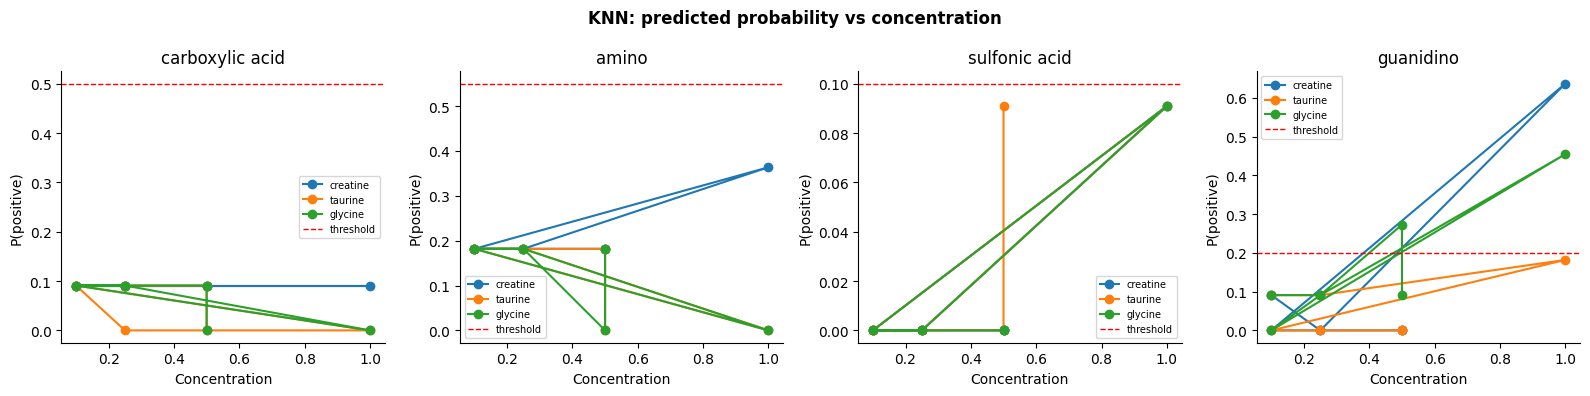

In [14]:
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('KNN: predicted probability vs concentration', fontweight='bold')

for i, (ax, col) in enumerate(zip(axes, CLASS_NAMES)):
    for adult in df_lab['adulterant'].dropna().unique():
        mask  = (df_lab['adulterant'] == adult).values
        conc  = df_lab.loc[mask, 'concentration'].values
        proba = y_proba_lab[mask, i]
        ax.plot(conc, proba, marker='o', label=adult)
    ax.axhline(optimal_thresholds[i], color='red', ls='--', lw=1, label='threshold')
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('Concentration')
    ax.set_ylabel('P(positive)')
    ax.legend(fontsize=7)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()